# Setup

In [1]:
import os
import logging
import warnings
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-02-24 17:47:32.517054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771955252.538132    1488 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771955252.544484    1488 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771955252.561143    1488 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771955252.561166    1488 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771955252.561169    1488 computation_placer.cc:177] computation placer alr

In [2]:
EPOCHS       = 100
BATCH_SIZE   = 64
PATIENCE_ES  = 10
PATIENCE_REDUCELR_ON_PLATEAU = 5

MODEL_PATH   = "best_model.keras"
TFLITE_PATH  = "model_simple_int8.tflite"
MONITOR_MET  = "val_accuracy"
LR = 0.01

IMG_SIZE = (32, 32)
INPUT_SHAPE = (*IMG_SIZE, 3)

AUTOTUNE = tf.data.AUTOTUNE

# Dataset

In [3]:
def get_datasets():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    y_train = y_train.flatten()
    y_test = y_test.flatten()

    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train = x_train[indices]
    y_train = y_train[indices]

    val_size = int(len(x_train) * 0.1)
    x_val, y_val = x_train[:val_size], y_train[:val_size]
    x_train, y_train = x_train[val_size:], y_train[val_size:]

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)

    print(f"Training samples: {len(x_train)}, Validation samples: {len(x_val)}, Test samples: {len(x_test)}")

    return train_ds, val_ds, test_ds

def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

def prepare_dataset(ds, is_training=False):
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

raw_train_ds, raw_val_ds, raw_test_ds = get_datasets()
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
train_ds = prepare_dataset(raw_train_ds, is_training=True)
val_ds = prepare_dataset(raw_val_ds)
test_ds = prepare_dataset(raw_test_ds)

I0000 00:00:1771955277.511886    1488 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training samples: 45000, Validation samples: 5000, Test samples: 10000


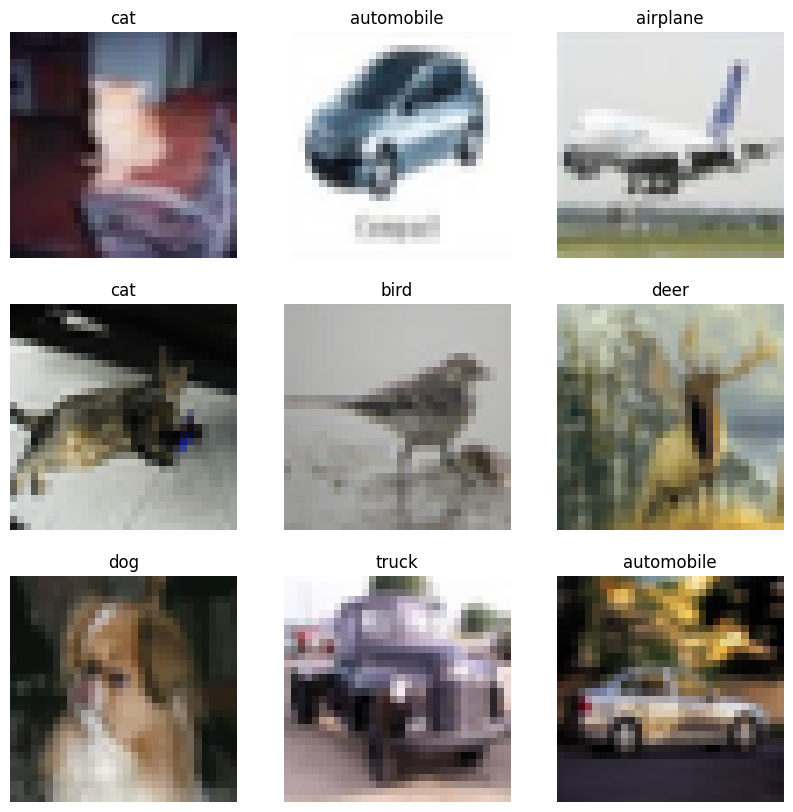

In [15]:
def plot_samples(dataset, class_names, num_samples=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            plt.subplot(3, 3, i + 1)
            img_array = images[i].numpy().astype("uint8")
            label_index = int(labels[i].numpy())
            plt.imshow(img_array)
            plt.title(class_names[label_index])
            plt.axis("off")
    plt.show()

plot_samples(raw_train_ds, CLASS_NAMES)

# Helpers

In [5]:
def get_callbacks():
    return [
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES, verbose=0, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH, monitor=MONITOR_MET, save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor=MONITOR_MET, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, verbose=1)
    ]

def plot_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

def evaluate_model(model, test_data):
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Test set accuracy: {acc:.4f}")
    return loss, acc

# Model

In [6]:
def create_balanced_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'), # Conv2D
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'), # Conv2D
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'), # Conv2D
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'), # Conv2D
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [7]:
model = create_balanced_model()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,994 (554.66 KB)

 Trainable params: 141,354 (552.16 KB)

 Non-trainable params: 640 (2.50 KB)

# Train

In [8]:
print(f"\n Start training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)


 Start training - 100 epochs (batch size=64)
Epoch 1/100


I0000 00:00:1771955292.806543    1546 service.cc:152] XLA service 0x7a2478017190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771955292.806575    1546 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771955293.368120    1546 cuda_dnn.cc:529] Loaded cuDNN version 91002


 27/704 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2157 - loss: 2.0787

I0000 00:00:1771955297.595280    1546 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.4415 - loss: 1.5314 - val_accuracy: 0.5872 - val_loss: 1.1262 - learning_rate: 0.0010
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6354 - loss: 1.0325 - val_accuracy: 0.6570 - val_loss: 0.9762 - learning_rate: 0.0010
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6932 - loss: 0.8810 - val_accuracy: 0.6694 - val_loss: 0.9628 - learning_rate: 0.0010
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7254 - loss: 0.7786 - val_accuracy: 0.7332 - val_loss: 0.7638 - learning_rate: 0.0010
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7501 - loss: 0.7100 - val_accuracy: 0.7524 - val_loss: 0.7121 - learning_rate: 0.0010
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7667 - loss: 0.6623 - val_accuracy: 0.6878 - val_loss: 0.9613 - learning_rate: 0.0010
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7852 - loss: 0.6167 - val

In [9]:
print("\n Evaluating on the test set")
evaluate_model(model, test_ds)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on the test set
Test set accuracy: 0.8600
Number of classes 10



 Plotting training curve


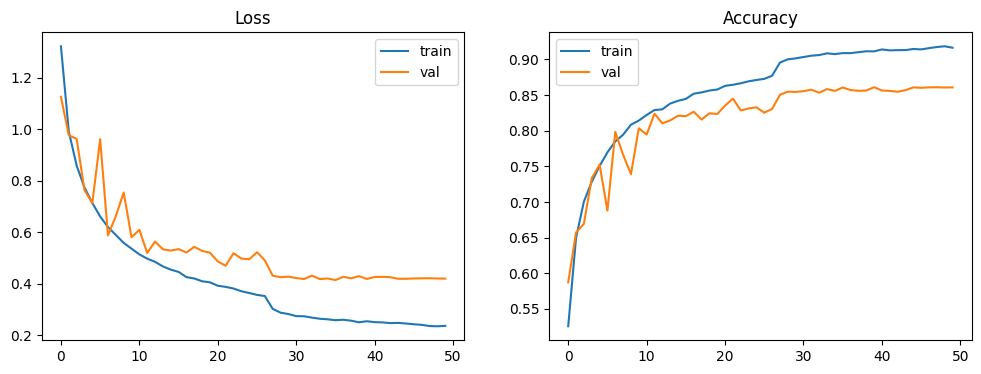

In [10]:
print("\n Plotting training curve")
plot_history(history)

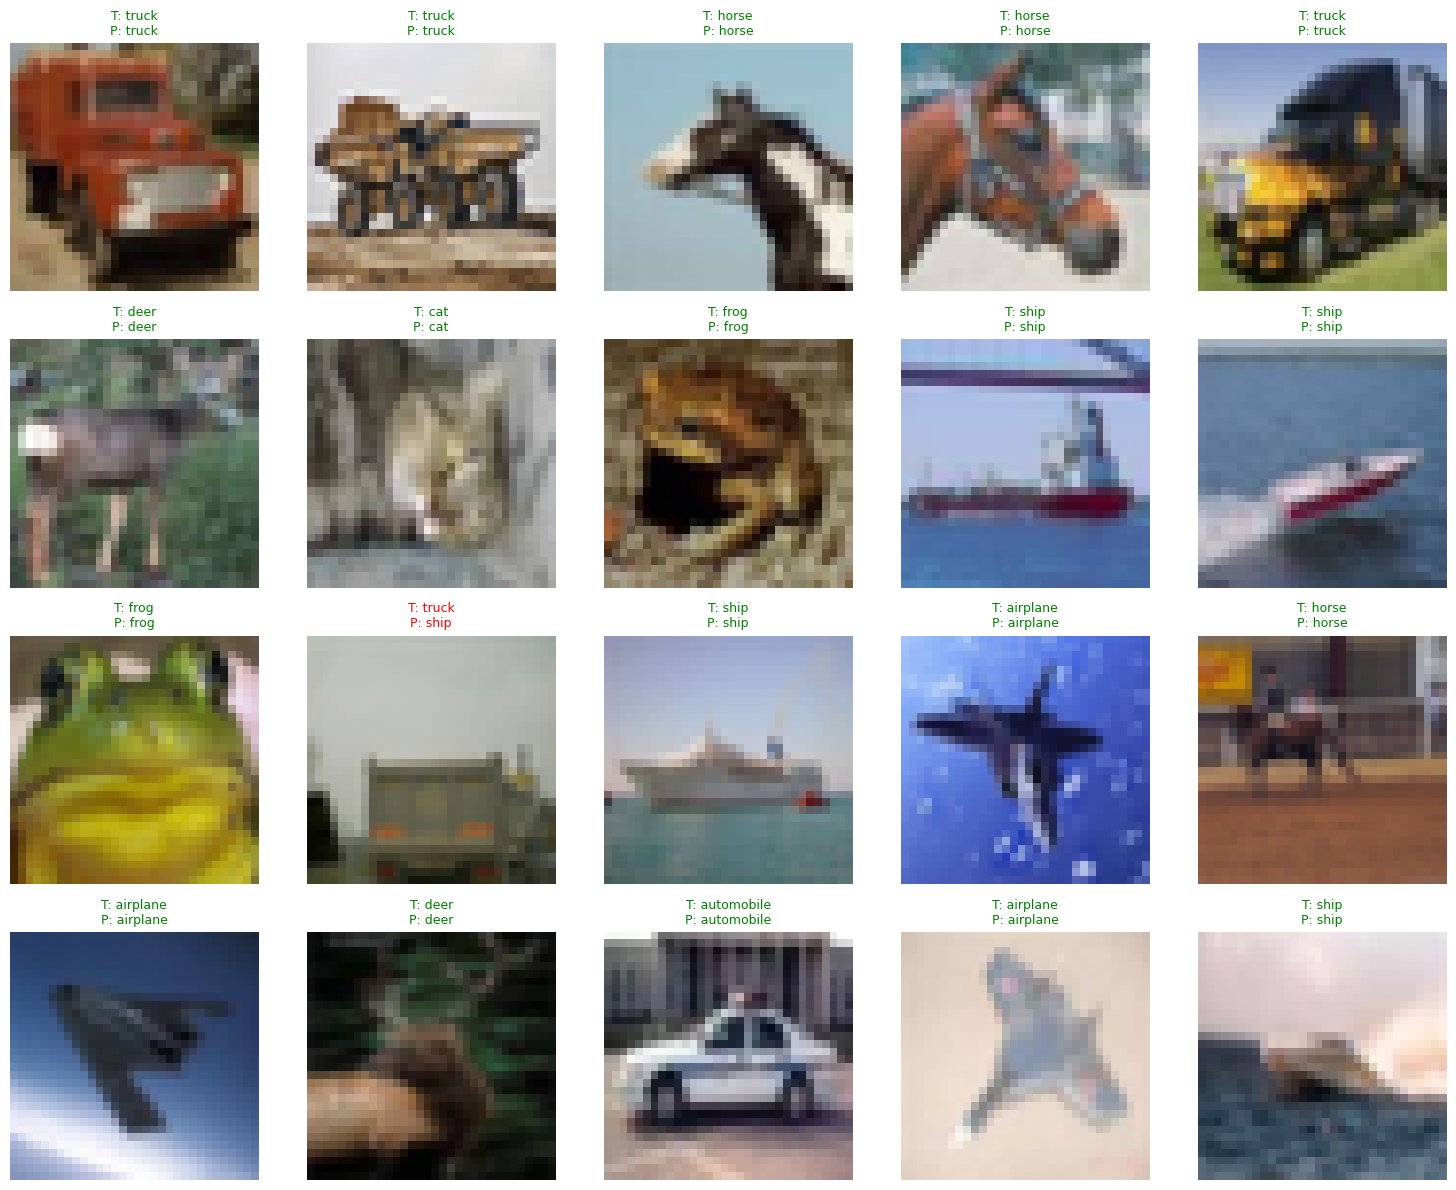

In [17]:
def predict_random_samples(model, dataset, class_names, num_samples=10):
    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)
    images, true_labels = [], []
    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(int(lbl.numpy()))
    images_arr = np.array(images)
    pred_labels = np.argmax(model.predict(images_arr, verbose=0), axis=1)
    rows = int(np.ceil(num_samples / 5))
    cols = min(num_samples, 5)
    plt.figure(figsize=(15, rows * 3))
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img_display = (images_arr[i] * 255).astype("uint8")
        plt.imshow(img_display)
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_random_samples(model, test_ds, CLASS_NAMES, num_samples=20)

# TFLite Export

In [12]:
%%time

def create_representative_dataset_generator(dataset, num_samples=20):
    def representative_dataset():
        for images, _ in dataset.take(num_samples).unbatch().batch(1):
            yield [tf.cast(images, tf.float32)]
    return representative_dataset

def export_quantized_tflite(keras_model, representative_dataset_gen, tflite_path):
    print(f"\n🛠️ Converting and quantizing to TFLite (INT8) in `{tflite_path}`...")

    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.int8

    tflite_model_quant = converter.convert()

    with open(tflite_path, "wb") as f:
        f.write(tflite_model_quant)

    keras_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    tflite_size_kb = len(tflite_model_quant) / 1024
    print(f"✅Export completed.  Keras: {keras_size_mb:.2f} MB |  TFLite: {tflite_size_kb:.1f} KB")



representative_data_gen = create_representative_dataset_generator(train_ds)
export_quantized_tflite(model, representative_data_gen, TFLITE_PATH)


🛠️ Converting and quantizing to TFLite (INT8) in `model_simple_int8.tflite`...
Saved artifact at '/tmp/tmpw4s57tjb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134300045252112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045252880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045254992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045255184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045252496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045253648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045254608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045253840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134300045255376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13430

W0000 00:00:1771955506.596826    1488 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771955506.596849    1488 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1771955506.615476    1488 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


✅Export completed.  Keras: 1.70 MB |  TFLite: 155.2 KB
CPU times: user 10.6 s, sys: 527 ms, total: 11.1 s
Wall time: 7.85 s


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: INT8


In [13]:
import numpy as np
import tensorflow as tf

def evaluate_tflite_universal(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero = input_details["quantization"]
    output_scale, output_zero = output_details["quantization"]

    correct = 0
    total = 0

    print(f"Testing TFLite Universal: {tflite_path}")

    for images, labels in dataset.unbatch().batch(1):
        img = images[0].numpy()
        lbl_raw = labels[0].numpy()

        if lbl_raw.size == 1:
            label = int(lbl_raw)
        else:
            label = np.argmax(lbl_raw)

        if input_details['dtype'] == np.uint8:
            img = img / input_scale + input_zero
            img = np.clip(img, 0, 255).astype(np.uint8)

        interpreter.set_tensor(input_details["index"], [img])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]

        if output_details['dtype'] != np.float32:
             output = (output.astype(np.float32) - output_zero) * output_scale

        pred = np.argmax(output)

        if pred == label:
            correct += 1
        total += 1

    acc = correct / total if total > 0 else 0
    print(f"Accuracy TFLite: {acc:.4f}")
    return acc

In [14]:
evaluate_tflite_universal(TFLITE_PATH, test_ds)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Testing TFLite Universal: model_simple_int8.tflite
Accuracy TFLite: 0.8419


0.8419

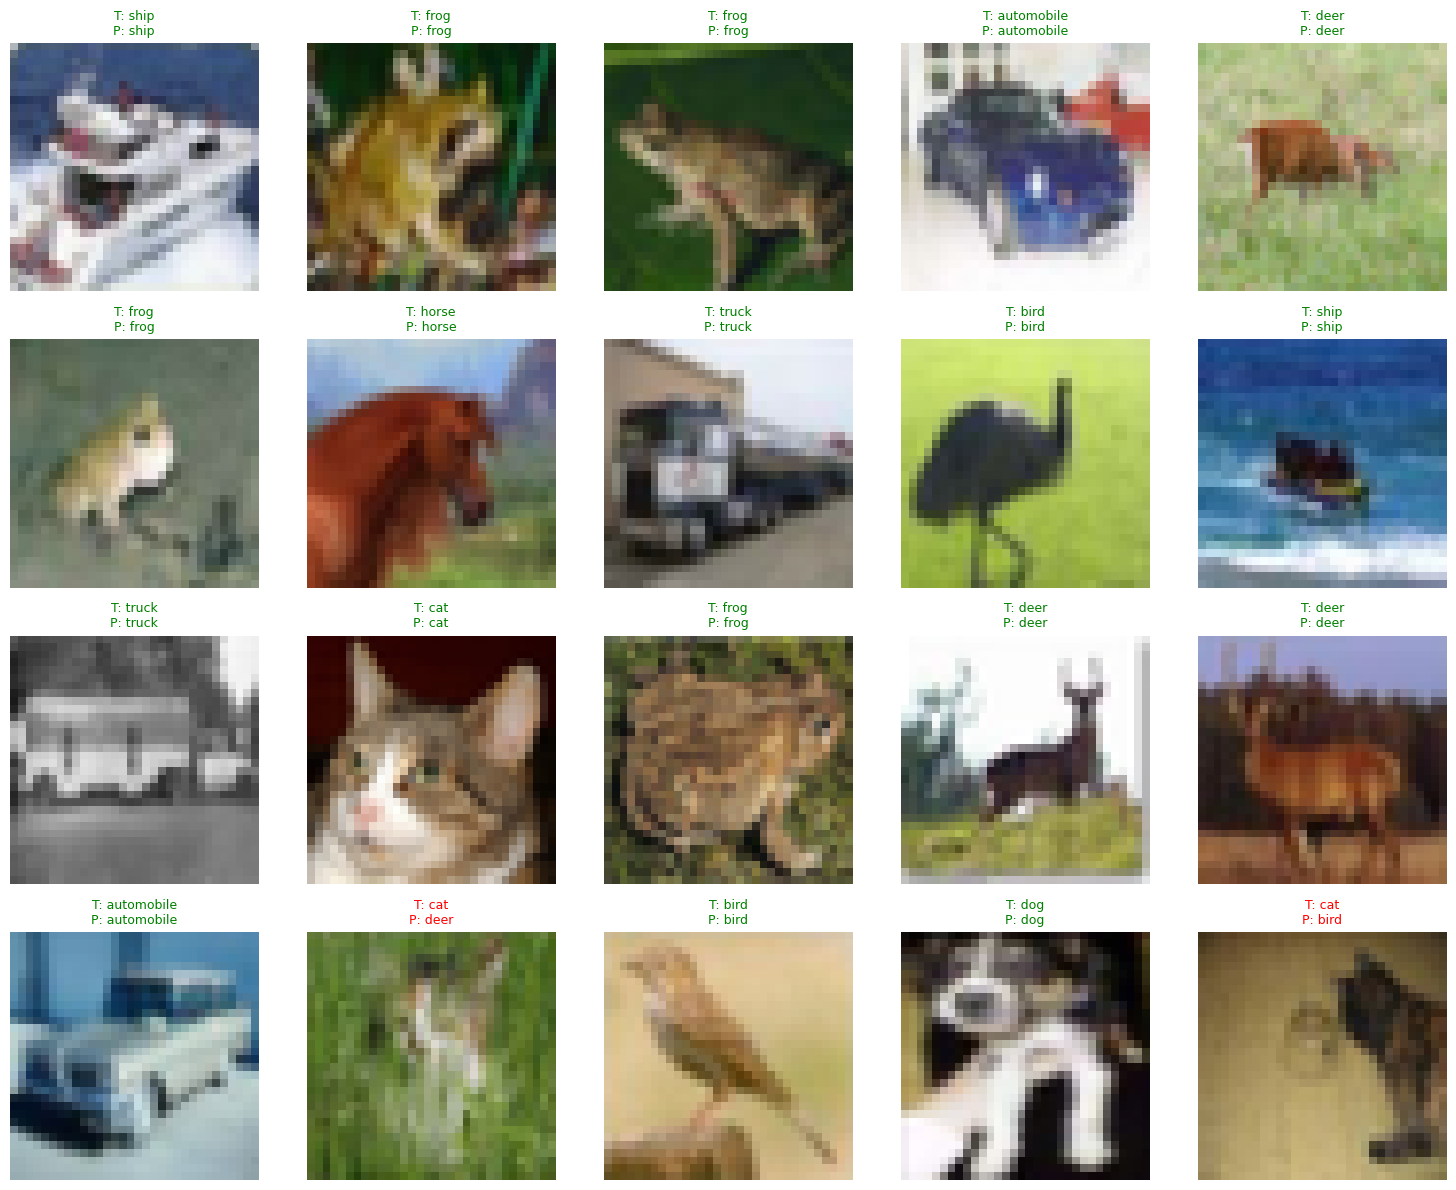

In [18]:
def predict_random_samples_tfliteint8(tflite_path, dataset, class_names, num_samples=20):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero = input_details["quantization"]
    output_scale, output_zero = output_details["quantization"]

    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)
    images, true_labels = [], []
    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(int(lbl.numpy()))

    pred_labels = []
    for img in images:
        inp = img.copy()
        if input_details["dtype"] == np.uint8:
            inp = inp / input_scale + input_zero
            inp = np.clip(inp, 0, 255).astype(np.uint8)
        interpreter.set_tensor(input_details["index"], inp[np.newaxis])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]
        if output_details["dtype"] != np.float32:
            output = (output.astype(np.float32) - output_zero) * output_scale
        pred_labels.append(np.argmax(output))

    rows = int(np.ceil(num_samples / 5))
    cols = min(num_samples, 5)
    plt.figure(figsize=(15, rows * 3))
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow((images[i] * 255).astype("uint8"))
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_random_samples_tfliteint8(TFLITE_PATH, test_ds, CLASS_NAMES, num_samples=20)